In [7]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

In [ ]:
# Analysis of Data Engineer jobs in India
df_DE_In = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Engineer')].copy()
df_DE_In

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,NaN,NaN,NaN,Hexaware Technologies,"[powershell, python, sql, mysql, sql server, d...","{'cloud': ['databricks', 'azure'], 'databases'..."
80,Data Engineer,Director - Enterprise Architecture and Data En...,"Chennai, Tamil Nadu, India",via Indeed,Full-time,False,India,2023-05-11 13:20:16,False,False,India,NaN,NaN,NaN,Ford Motor Company,"[gcp, graphql, kubernetes]","{'cloud': ['gcp'], 'libraries': ['graphql'], '..."
95,Data Engineer,Data Engineer,"Mumbai, Maharashtra, India",via Crimsoniteam.freshteam.com,Full-time,False,India,2023-07-31 13:35:48,False,False,India,NaN,NaN,NaN,Crimson Interactive Inc,"[nosql, mongodb, mongodb, elasticsearch, mysql...","{'analyst_tools': ['tableau'], 'databases': ['..."
149,Data Engineer,Data Engineering Lead,"New Delhi, Delhi, India",via LinkedIn,Full-time,False,India,2023-04-11 13:55:10,True,False,India,NaN,NaN,NaN,Axtria - Ingenious Insights,"[python, sql, aws, azure, gcp, spark, tableau,...","{'analyst_tools': ['tableau', 'microstrategy',..."
210,Data Engineer,Azure Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-03-06 14:00:44,True,False,India,NaN,NaN,NaN,Mississippi Consultants LLP,"[sql, python, databricks, azure, pyspark, pand...","{'analyst_tools': ['power bi'], 'cloud': ['dat..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785584,Data Engineer,Data Engineer,"Bengaluru, Karnataka, India",via BeBee India,Full-time,False,India,2023-01-01 06:29:29,False,False,India,NaN,NaN,NaN,Alcon,"[python, scala, java, sql, aws, redshift, spri...","{'async': ['jira', 'confluence'], 'cloud': ['a..."
785636,Data Engineer,Data Engineer,"Bengaluru, Karnataka, India",via LinkedIn,Full-time,False,India,2023-01-03 06:25:53,False,False,India,NaN,NaN,NaN,TMRW House of Brands,"[mongodb, mongodb, python, postgresql, spark, ...","{'databases': ['mongodb', 'postgresql'], 'libr..."
785684,Data Engineer,Data Engineer,"Noida, Uttar Pradesh, India",via LinkedIn,Full-time,False,India,2023-01-11 06:28:41,False,False,India,NaN,NaN,NaN,Deuglo Infosystem Private Limited,"[sql, shell, python, aws]","{'cloud': ['aws'], 'programming': ['sql', 'she..."
785695,Data Engineer,AWS Data Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-05 06:35:07,False,False,India,NaN,NaN,NaN,LatentView Analytics,"[python, sql, scala, aws, snowflake, databrick...","{'cloud': ['aws', 'snowflake', 'databricks'], ..."


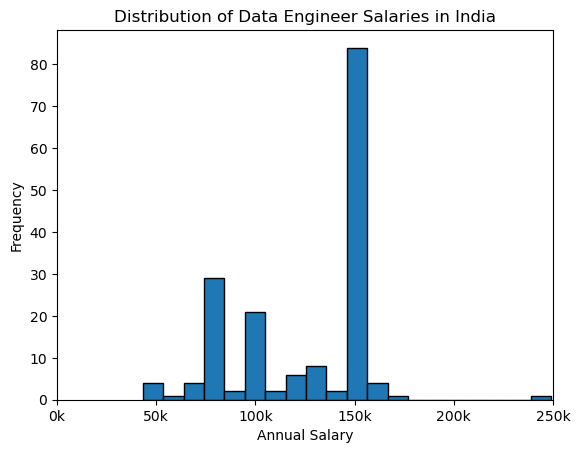

In [18]:
import matplotlib.ticker as ticker

# Create histogram and capture axes
ax = df_DE_In['salary_year_avg'].plot(kind='hist', bins=20, edgecolor='black')
plt.xlim(0, 250000)

# Format x-axis with FuncFormatter (show as 20k, 30k, 100k, etc.)
def format_salary(x, pos):
    return f'{x/1000:.0f}k'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Add labels and title
plt.xlabel('Annual Salary')
plt.ylabel('Frequency')
plt.title('Distribution of Data Engineer Salaries in India')

plt.show()